# 02 · Pipeline Deep Dive: Real Sentiment Classification (NLTK movie_reviews)

Companion notebook for `02-ML-Pipeline-Hands-On.md` (Sections 15–23, especially Section 22). The class demo used 5 hand-written reviews and 2 weak features, so it scored 20%. Here the **same pipeline** runs on a real corpus with real features:

1. **Part A:** Load 2,000 labelled IMDb-style movie reviews (Pang & Lee, 2004) from NLTK
2. **Part B:** TF-IDF by hand on a 3-document corpus, checked against scikit-learn
3. **Part C:** TF-IDF + logistic regression, stratified 5-fold cross-validation, choosing `C`
4. **Part D:** Final test evaluation: confusion matrix, classification report
5. **Part E:** ROC and precision–recall curves, AUC
6. **Part F:** Threshold tuning (on cross-validated train predictions, never on test)
7. **Part G:** What did the model learn? Top positive / negative words
8. **Part H:** Imbalanced variant: why accuracy lies
9. **Part I:** Data leakage demos (scaling before vs after split; feature selection before split)
10. **Part J:** Logistic regression from scratch: one gradient step by hand
11. **Part K:** Imbalanced data done right: PR-AUC and an out-of-fold threshold
12. **Part L:** Full logistic regression by gradient descent, compared with scikit-learn
13. **Part M:** Checking the note's worked examples (metrics, sigmoid, scaling, CV)

## Part A — Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate,
                                     cross_val_predict, GridSearchCV, cross_val_score)
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, roc_auc_score,
                             average_precision_score, roc_curve, precision_recall_curve,
                             precision_score, recall_score, f1_score, ConfusionMatrixDisplay)
np.set_printoptions(precision=4, suppress=True)
nltk.download("movie_reviews", quiet=True)
from nltk.corpus import movie_reviews as mr

In [2]:
fileids = mr.fileids()
docs = [mr.raw(f) for f in fileids]
y = np.array([1 if f.startswith("pos") else 0 for f in fileids])   # 1 = positive, 0 = negative
lengths = np.array([len(d.split()) for d in docs])
print("documents:", len(docs), "| positive:", y.sum(), "| negative:", (y == 0).sum())
print("words per review: mean %.0f, min %d, max %d" % (lengths.mean(), lengths.min(), lengths.max()))
print("\nFirst 300 characters of a positive review:\n", docs[y.argmax()][:300])

documents: 2000 | positive: 1000 | negative: 1000
words per review: mean 746, min 17, max 2678

First 300 characters of a positive review:
 films adapted from comic books have had plenty of success , whether they're about superheroes ( batman , superman , spawn ) , or geared toward kids ( casper ) or the arthouse crowd ( ghost world ) , but there's never really been a comic book like from hell before . 
for starters , it was created by 


In [3]:
# Hold out a TEST set first. It is touched exactly once, at the very end (Part D).
X_train, X_test, y_train, y_test = train_test_split(
    docs, y, test_size=0.2, random_state=42, stratify=y)
print(len(X_train), "train /", len(X_test), "test | positive share:",
      y_train.mean(), "/", y_test.mean())

1600 train / 400 test | positive share: 0.5 / 0.5


## Part B — TF-IDF by hand (3-document corpus)

scikit-learn's default (`smooth_idf=True`, `norm="l2"`):

$\text{idf}(t) = \ln\frac{1+N}{1+\text{df}(t)} + 1$, then $\text{tfidf}(t,d) = \text{tf}(t,d)\cdot\text{idf}(t)$, then each row is divided by its L2 norm.

In [4]:
corpus = ["good movie good plot", "bad movie", "good acting bad plot"]
cv_ = CountVectorizer().fit(corpus)
tf = cv_.transform(corpus).toarray()
vocab = cv_.get_feature_names_out()
N = len(corpus)
df = (tf > 0).sum(axis=0)
idf = np.log((1 + N) / (1 + df)) + 1
raw = tf * idf
manual = raw / np.linalg.norm(raw, axis=1, keepdims=True)
print(pd.DataFrame({"df": df, "idf": idf.round(4)}, index=vocab).T)
print("\nraw tf*idf:\n", pd.DataFrame(raw.round(4), columns=vocab))
print("\nL2-normalised (manual):\n", pd.DataFrame(manual.round(4), columns=vocab))
sk = TfidfVectorizer().fit_transform(corpus).toarray()
print("\nmatches sklearn TfidfVectorizer:", np.allclose(manual, sk))

     acting     bad    good   movie    plot
df   1.0000  2.0000  2.0000  2.0000  2.0000
idf  1.6931  1.2877  1.2877  1.2877  1.2877

raw tf*idf:
    acting     bad    good   movie    plot
0  0.0000  0.0000  2.5754  1.2877  1.2877
1  0.0000  1.2877  0.0000  1.2877  0.0000
2  1.6931  1.2877  1.2877  0.0000  1.2877

L2-normalised (manual):
    acting     bad    good   movie    plot
0  0.0000  0.0000  0.8165  0.4082  0.4082
1  0.0000  0.7071  0.0000  0.7071  0.0000
2  0.6047  0.4599  0.4599  0.0000  0.4599

matches sklearn TfidfVectorizer: True


## Part C — Model selection with stratified 5-fold CV (train set only)

`make_pipeline` glues TF-IDF and the classifier together, so in every CV fold the vocabulary and IDF are re-learnt from that fold's training part only (no leakage). `C` is the inverse regularisation strength: small `C` = strong L2 penalty.

In [5]:
pipe = make_pipeline(TfidfVectorizer(min_df=2, ngram_range=(1, 2), sublinear_tf=True),
                     LogisticRegression(max_iter=2000))
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(pipe, {"logisticregression__C": [0.1, 1, 10, 100]}, cv=skf, scoring="accuracy")
grid.fit(X_train, y_train)
res = pd.DataFrame(grid.cv_results_)[["param_logisticregression__C", "mean_test_score", "std_test_score"]]
print(res.round(4).to_string(index=False))
print("best C:", grid.best_params_["logisticregression__C"])

 param_logisticregression__C  mean_test_score  std_test_score
                         0.1           0.8387          0.0191
                         1.0           0.8588          0.0144
                        10.0           0.8738          0.0108
                       100.0           0.8781          0.0127
best C: 100


In [6]:
best = grid.best_estimator_
scores = cross_validate(best, X_train, y_train, cv=skf, scoring=["accuracy", "f1", "roc_auc"])
for k in ["test_accuracy", "test_f1", "test_roc_auc"]:
    s = scores[k]
    print(f"{k[5:]:9s} per fold {s.round(4)}  ->  {s.mean():.4f} ± {s.std():.4f}")

accuracy  per fold [0.8938 0.8625 0.8656 0.8781 0.8906]  ->  0.8781 ± 0.0127
f1        per fold [0.891  0.8625 0.8701 0.877  0.8896]  ->  0.8780 ± 0.0110
roc_auc   per fold [0.9527 0.9435 0.9505 0.9354 0.9623]  ->  0.9489 ± 0.0090


## Part D — Final evaluation on the untouched test set

accuracy: 0.8725
confusion matrix [[TN, FP], [FN, TP]]:
 [[172  28]
 [ 23 177]]
TN=172 FP=28 FN=23 TP=177
              precision    recall  f1-score   support

         neg      0.882     0.860     0.871       200
         pos      0.863     0.885     0.874       200

    accuracy                          0.873       400
   macro avg      0.873     0.873     0.872       400
weighted avg      0.873     0.873     0.872       400



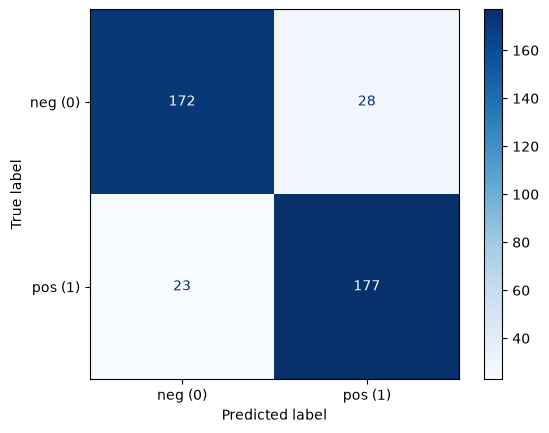

In [7]:
best.fit(X_train, y_train)                       # refit on all 1,600 training reviews
p_test = best.predict_proba(X_test)[:, 1]        # P(positive)
y_pred = (p_test >= 0.5).astype(int)             # same as best.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print("accuracy:", accuracy_score(y_test, y_pred))
print("confusion matrix [[TN, FP], [FN, TP]]:\n", cm)
print(f"TN={tn} FP={fp} FN={fn} TP={tp}")
print(classification_report(y_test, y_pred, target_names=["neg", "pos"], digits=3))
ConfusionMatrixDisplay(cm, display_labels=["neg (0)", "pos (1)"]).plot(cmap="Blues"); plt.show()

## Part E — ROC and precision–recall curves

ROC AUC = 0.9546 | average precision (area under PR) = 0.9605


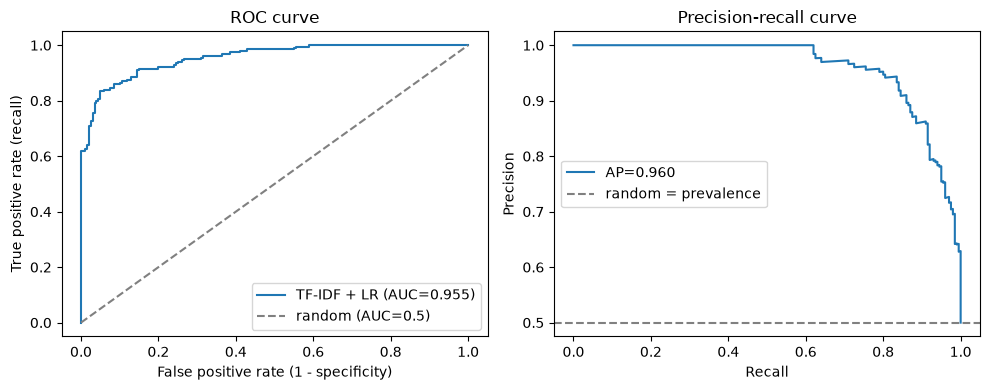

In [8]:
fpr, tpr, thr_roc = roc_curve(y_test, p_test)
prec, rec, thr_pr = precision_recall_curve(y_test, p_test)
auc = roc_auc_score(y_test, p_test); ap = average_precision_score(y_test, p_test)
print(f"ROC AUC = {auc:.4f} | average precision (area under PR) = {ap:.4f}")
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(fpr, tpr, label=f"TF-IDF + LR (AUC={auc:.3f})"); ax[0].plot([0, 1], [0, 1], "--", c="gray", label="random (AUC=0.5)")
ax[0].set(xlabel="False positive rate (1 - specificity)", ylabel="True positive rate (recall)", title="ROC curve"); ax[0].legend()
ax[1].plot(rec, prec, label=f"AP={ap:.3f}"); ax[1].axhline(y_test.mean(), ls="--", c="gray", label="random = prevalence")
ax[1].set(xlabel="Recall", ylabel="Precision", title="Precision-recall curve"); ax[1].legend()
plt.tight_layout(); plt.show()

In [9]:
# AUC = probability that a random positive gets a higher score than a random negative
pos, neg = p_test[y_test == 1], p_test[y_test == 0]
pairs = (pos[:, None] > neg[None, :]).mean() + 0.5 * (pos[:, None] == neg[None, :]).mean()
print(f"pairwise ranking estimate = {pairs:.4f}  (equals roc_auc_score: {np.isclose(pairs, auc)})")

pairwise ranking estimate = 0.9546  (equals roc_auc_score: True)


## Part F — Threshold tuning

The threshold is a hyperparameter, so it is chosen on **out-of-fold training predictions** (`cross_val_predict`), never on the test set.

In [10]:
p_oof = cross_val_predict(best, X_train, y_train, cv=skf, method="predict_proba")[:, 1]
rows = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    yp = (p_oof >= t).astype(int)
    rows.append([t, precision_score(y_train, yp), recall_score(y_train, yp), f1_score(y_train, yp), accuracy_score(y_train, yp)])
print(pd.DataFrame(rows, columns=["threshold", "precision", "recall", "F1", "accuracy"]).round(4).to_string(index=False))

 threshold  precision  recall     F1  accuracy
       0.3     0.7608  0.9662 0.8513    0.8312
       0.4     0.8152  0.9262 0.8672    0.8581
       0.5     0.8795  0.8762 0.8779    0.8781
       0.6     0.9256  0.8088 0.8632    0.8719
       0.7     0.9505  0.7200 0.8193    0.8412


In [11]:
# Example policy: the smallest threshold that keeps precision >= 0.90 on out-of-fold predictions
ts = np.linspace(0.05, 0.95, 181)
ok = [t for t in ts if precision_score(y_train, (p_oof >= t).astype(int), zero_division=0) >= 0.90]
t_star = min(ok)
yp = (p_test >= t_star).astype(int)
print(f"chosen threshold = {t_star:.3f}")
print(f"TEST at t*: precision={precision_score(y_test, yp):.4f} recall={recall_score(y_test, yp):.4f} "
      f"F1={f1_score(y_test, yp):.4f}")
print("TEST confusion matrix at t*:\n", confusion_matrix(y_test, yp))

chosen threshold = 0.540
TEST at t*: precision=0.8832 recall=0.8700 F1=0.8766
TEST confusion matrix at t*:
 [[177  23]
 [ 26 174]]


## Part G — What did the model learn?

In [12]:
vec = best.named_steps["tfidfvectorizer"]; lr = best.named_steps["logisticregression"]
names = vec.get_feature_names_out(); w = lr.coef_[0]
order = np.argsort(w)
print("vocabulary size:", len(names), "| bias:", round(float(lr.intercept_[0]), 4))
print("\nTop 15 POSITIVE words:"); print([(names[i], round(float(w[i]), 3)) for i in order[::-1][:15]])
print("\nTop 15 NEGATIVE words:"); print([(names[i], round(float(w[i]), 3)) for i in order[:15]])

vocabulary size: 116452 | bias: -0.2749

Top 15 POSITIVE words:
[('great', 4.756), ('the best', 4.489), ('excellent', 4.05), ('perfect', 4.037), ('well', 4.031), ('hilarious', 3.937), ('very', 3.929), ('also', 3.894), ('overall', 3.822), ('he is', 3.754), ('fun', 3.669), ('perfectly', 3.559), ('terrific', 3.557), ('as the', 3.521), ('both', 3.488)]

Top 15 NEGATIVE words:
[('bad', -8.382), ('worst', -6.07), ('boring', -5.166), ('nothing', -5.115), ('script', -4.608), ('plot', -4.544), ('supposed', -4.363), ('unfortunately', -4.261), ('ridiculous', -4.256), ('the worst', -4.243), ('should have', -4.194), ('only', -4.148), ('mess', -3.995), ('supposed to', -3.976), ('have', -3.965)]


In [13]:
for s in ["an outstanding, moving film with a wonderful cast",
          "boring, stupid and a complete waste of time",
          "the plot was ok but the acting was bad"]:
    print(f"{best.predict_proba([s])[0, 1]:.3f}  {s}")

0.864  an outstanding, moving film with a wonderful cast
0.011  boring, stupid and a complete waste of time
0.048  the plot was ok but the acting was bad


## Part H — Imbalanced variant: accuracy lies

Keep all 1,000 negative reviews but only 100 positive ones (9% positive), like a rare-event problem.

In [14]:
rng = np.random.default_rng(0)
pos_idx = rng.choice(np.where(y == 1)[0], 100, replace=False)
idx = np.concatenate([np.where(y == 0)[0], pos_idx])
docs_im = [docs[i] for i in idx]; y_im = y[idx]
Xa, Xb, ya, yb = train_test_split(docs_im, y_im, test_size=0.3, random_state=42, stratify=y_im)
print("test size:", len(yb), "| positives in test:", yb.sum())
for name, model in [("always predict 0", None),
                    ("LR (default)", make_pipeline(TfidfVectorizer(min_df=2, sublinear_tf=True), LogisticRegression(C=10, max_iter=2000))),
                    ("LR class_weight=balanced", make_pipeline(TfidfVectorizer(min_df=2, sublinear_tf=True), LogisticRegression(C=10, max_iter=2000, class_weight="balanced")))]:
    yp = np.zeros_like(yb) if model is None else model.fit(Xa, ya).predict(Xb)
    print(f"{name:26s} acc={accuracy_score(yb, yp):.4f} prec={precision_score(yb, yp, zero_division=0):.4f} "
          f"rec={recall_score(yb, yp):.4f} F1={f1_score(yb, yp):.4f}  CM={confusion_matrix(yb, yp).tolist()}")

test size: 330 | positives in test: 30
always predict 0           acc=0.9091 prec=0.0000 rec=0.0000 F1=0.0000  CM=[[300, 0], [30, 0]]


LR (default)               acc=0.9091 prec=0.0000 rec=0.0000 F1=0.0000  CM=[[300, 0], [30, 0]]


LR class_weight=balanced   acc=0.9152 prec=1.0000 rec=0.0667 F1=0.1250  CM=[[300, 0], [28, 2]]


## Part I — Data leakage demos

**I-1. Scaling before vs after the split.** On well-behaved data the difference is small, but the before-split number is not an honest estimate, because test-set statistics shaped the training inputs.

In [15]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
Xc, yc = load_breast_cancer(return_X_y=True)
diffs = []
for seed in range(20):
    # WRONG: scaler sees all rows, then split
    Xs = StandardScaler().fit_transform(Xc)
    a, b, ya_, yb_ = train_test_split(Xs, yc, test_size=0.3, random_state=seed, stratify=yc)
    acc_wrong = LogisticRegression(max_iter=5000).fit(a, ya_).score(b, yb_)
    # RIGHT: split, then fit scaler on train only
    a, b, ya_, yb_ = train_test_split(Xc, yc, test_size=0.3, random_state=seed, stratify=yc)
    sc = StandardScaler().fit(a)
    acc_right = LogisticRegression(max_iter=5000).fit(sc.transform(a), ya_).score(sc.transform(b), yb_)
    diffs.append((acc_wrong, acc_right))
d = np.array(diffs)
print(f"mean accuracy  scale-before-split = {d[:,0].mean():.4f} | scale-after-split = {d[:,1].mean():.4f}")
print("seeds where the two differ:", int((d[:,0] != d[:,1]).sum()), "of 20")

mean accuracy  scale-before-split = 0.9749 | scale-after-split = 0.9743
seeds where the two differ: 2 of 20


In [16]:
# Where the scaler's numbers come from: mean/std of one feature with and without the test rows
a, b, _, _ = train_test_split(Xc, yc, test_size=0.3, random_state=0, stratify=yc)
print("feature 0 mean: all rows %.4f | train only %.4f" % (Xc[:, 0].mean(), a[:, 0].mean()))
print("feature 0 std : all rows %.4f | train only %.4f" % (Xc[:, 0].std(), a[:, 0].std()))

feature 0 mean: all rows 14.1273 | train only 14.1044
feature 0 std : all rows 3.5210 | train only 3.6181


**I-2. Feature selection before the split (the dramatic one).** Pure noise: 100 samples, 10,000 random features, random labels. True accuracy of any model is 50%.

In [17]:
from sklearn.feature_selection import SelectKBest, f_classif
rng = np.random.default_rng(1)
Xn = rng.normal(size=(100, 10000)); yn = rng.integers(0, 2, 100)
cvn = StratifiedKFold(5, shuffle=True, random_state=0)
# WRONG: choose the 20 'best' features using ALL labels, then cross-validate
Xsel = SelectKBest(f_classif, k=20).fit_transform(Xn, yn)
wrong = cross_val_score(LogisticRegression(max_iter=2000), Xsel, yn, cv=cvn)
# RIGHT: selection inside the pipeline, re-done in every fold
right = cross_val_score(make_pipeline(SelectKBest(f_classif, k=20), LogisticRegression(max_iter=2000)), Xn, yn, cv=cvn)
print(f"select-then-CV (leaky): {wrong.mean():.3f} ± {wrong.std():.3f}")
print(f"CV-with-selection-inside (honest): {right.mean():.3f} ± {right.std():.3f}")

select-then-CV (leaky): 0.880 ± 0.081
CV-with-selection-inside (honest): 0.520 ± 0.075


## Part J — Logistic regression from scratch: one gradient step

Binary cross-entropy $J(w,b) = -\frac{1}{n}\sum_i [y_i\ln p_i + (1-y_i)\ln(1-p_i)]$ has gradient $\nabla_w J = \frac{1}{n}X^\top(p - y)$, $\partial J/\partial b = \frac{1}{n}\sum_i (p_i - y_i)$.

In [18]:
sig = lambda z: 1 / (1 + np.exp(-z))
X4 = np.array([[1.0, 2.0], [2.0, 1.0], [3.0, 3.0], [0.0, 1.0]]); y4 = np.array([0, 0, 1, 1])
w = np.array([0.5, -0.5]); b = 0.0; eta = 0.1
def bce(w, b):
    p = sig(X4 @ w + b); return -np.mean(y4 * np.log(p) + (1 - y4) * np.log(1 - p))
p = sig(X4 @ w + b)
gw = X4.T @ (p - y4) / len(y4); gb = np.mean(p - y4)
print("z =", X4 @ w + b, "\np =", p.round(4))
print("loss before =", round(bce(w, b), 4))
print("grad w =", gw.round(4), " grad b =", round(gb, 4))
w1, b1 = w - eta * gw, b - eta * gb
print("w after =", w1.round(4), " b after =", round(b1, 4), " loss after =", round(bce(w1, b1), 4))
# numerical check of the gradient
eps = 1e-6
num = [(bce(w + eps * np.eye(2)[j], b) - bce(w - eps * np.eye(2)[j], b)) / (2 * eps) for j in range(2)]
print("finite-difference grad w =", np.round(num, 4))

z = [-0.5  0.5  0.  -0.5] 
p = [0.3775 0.6225 0.5    0.3775]
loss before = 0.7788
grad w = [ 0.0306 -0.1862]  grad b = -0.0306
w after = [ 0.4969 -0.4814]  b after = 0.0031  loss after = 0.7753
finite-difference grad w = [ 0.0306 -0.1862]


## Part K — Imbalanced data done right

Part H showed that at the default threshold 0.5 the balanced model finds only 2 of 30 positives. The ranking is far better than that: the fix is to pick the threshold from **out-of-fold** training predictions and to judge the model by **PR-AUC (average precision)**, whose random baseline is the prevalence (about 0.09 here), not 0.5.

In [19]:
m_im = make_pipeline(TfidfVectorizer(min_df=2, sublinear_tf=True),
                     LogisticRegression(C=10, max_iter=2000, class_weight="balanced"))
cv_im = StratifiedKFold(5, shuffle=True, random_state=42)
p_oof_im = cross_val_predict(m_im, Xa, ya, cv=cv_im, method="predict_proba")[:, 1]
print(f"prevalence (train) = {ya.mean():.4f}")
print(f"OOF ROC-AUC = {roc_auc_score(ya, p_oof_im):.4f} | OOF average precision = {average_precision_score(ya, p_oof_im):.4f}")
pr_, rc_, th_ = precision_recall_curve(ya, p_oof_im)
f1_ = 2 * pr_ * rc_ / (pr_ + rc_ + 1e-12)
i = np.argmax(f1_[:-1]); t_im = th_[i]
print(f"F1-maximising OOF threshold = {t_im:.4f} (OOF precision={pr_[i]:.4f}, recall={rc_[i]:.4f}, F1={f1_[i]:.4f})")

prevalence (train) = 0.0909
OOF ROC-AUC = 0.9138 | OOF average precision = 0.5156
F1-maximising OOF threshold = 0.2117 (OOF precision=0.4778, recall=0.6143, F1=0.5375)


In [20]:
m_im.fit(Xa, ya); p_te_im = m_im.predict_proba(Xb)[:, 1]
print(f"TEST ROC-AUC = {roc_auc_score(yb, p_te_im):.4f} | TEST average precision = {average_precision_score(yb, p_te_im):.4f}")
for t in [0.5, t_im]:
    yp = (p_te_im >= t).astype(int)
    print(f"t={t:.4f}  acc={accuracy_score(yb, yp):.4f} prec={precision_score(yb, yp, zero_division=0):.4f} "
          f"rec={recall_score(yb, yp):.4f} F1={f1_score(yb, yp):.4f} CM={confusion_matrix(yb, yp).tolist()}")

TEST ROC-AUC = 0.8668 | TEST average precision = 0.4958
t=0.5000  acc=0.9152 prec=1.0000 rec=0.0667 F1=0.1250 CM=[[300, 0], [28, 2]]
t=0.2117  acc=0.8939 prec=0.4390 rec=0.6000 F1=0.5070 CM=[[277, 23], [12, 18]]


Accuracy *drops* slightly (0.915 to 0.894) while recall rises from 0.07 to 0.60 and F1 from 0.13 to about 0.51. On rare-event problems, accuracy is the wrong scoreboard.

## Part L — Logistic regression by full-batch gradient descent

Breast-cancer data (569 × 30), standardised with train statistics. We minimise the regularised objective that scikit-learn uses, $\frac{1}{2}\lVert w\rVert^2 + C\sum_i \ell_i$, divided by $nC$ so the step size is scale-free, and compare with `LogisticRegression(C=1)`.

In [21]:
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.3, random_state=0, stratify=yc)
sc = StandardScaler().fit(Xc_tr); A, B = sc.transform(Xc_tr), sc.transform(Xc_te)
n, d = A.shape; Cr = 1.0
def objective(w, b):
    z = A @ w + b
    return (np.sum(np.logaddexp(0, -z * (2 * yc_tr - 1))) + 0.5 * w @ w / Cr) / n
w = np.zeros(d); b = 0.0; eta = 0.5; hist = []
for it in range(5000):
    p = sig(A @ w + b)
    gw = (A.T @ (p - yc_tr) + w / Cr) / n
    gb = np.mean(p - yc_tr)
    w -= eta * gw; b -= eta * gb
    if it in (0, 9, 99, 999, 4999): hist.append((it + 1, objective(w, b)))
for it, J in hist: print(f"iteration {it:5d}: objective = {J:.6f}")
sk = LogisticRegression(C=Cr, max_iter=10000).fit(A, yc_tr)
print("max |w_gd - w_sklearn| =", np.abs(w - sk.coef_[0]).max().round(5), "| b_gd =", round(b, 4), " b_sk =", round(float(sk.intercept_[0]), 4))
print("test accuracy GD =", accuracy_score(yc_te, (sig(B @ w + b) >= 0.5).astype(int)), "| sklearn =", sk.score(B, yc_te))

iteration     1: objective = 0.222602
iteration    10: objective = 0.117562
iteration   100: objective = 0.070265
iteration  1000: objective = 0.064048
iteration  5000: objective = 0.063966
max |w_gd - w_sklearn| = 0.01216 | b_gd = 0.3432  b_sk = 0.3432
test accuracy GD = 0.9590643274853801 | sklearn = 0.9590643274853801


## Part M — Checking the worked examples in the note

In [22]:
def from_cm(TP, FN, FP, TN):
    yt = np.r_[np.ones(TP + FN), np.zeros(FP + TN)].astype(int)
    yp = np.r_[np.ones(TP), np.zeros(FN), np.ones(FP), np.zeros(TN)].astype(int)
    return yt, yp
from sklearn.metrics import fbeta_score, matthews_corrcoef, balanced_accuracy_score
for name, cm_ in [("A balanced", (40, 10, 5, 45)), ("B class demo", (0, 2, 2, 1)), ("C fraud", (8, 2, 40, 950))]:
    yt, yp = from_cm(*cm_)
    print(f"{name:13s} acc={accuracy_score(yt, yp):.4f} P={precision_score(yt, yp, zero_division=0):.4f} "
          f"R={recall_score(yt, yp):.4f} spec={recall_score(1 - yt, 1 - yp):.4f} F1={f1_score(yt, yp, zero_division=0):.4f} "
          f"F2={fbeta_score(yt, yp, beta=2, zero_division=0):.4f} F0.5={fbeta_score(yt, yp, beta=0.5, zero_division=0):.4f} "
          f"bal_acc={balanced_accuracy_score(yt, yp):.4f} MCC={matthews_corrcoef(yt, yp):.4f}")

A balanced    acc=0.8500 P=0.8889 R=0.8000 spec=0.9000 F1=0.8421 F2=0.8163 F0.5=0.8696 bal_acc=0.8500 MCC=0.7035
B class demo  acc=0.2000 P=0.0000 R=0.0000 spec=0.3333 F1=0.0000 F2=0.0000 F0.5=0.0000 bal_acc=0.1667 MCC=-0.6667
C fraud       acc=0.9580 P=0.1667 R=0.8000 spec=0.9596 F1=0.2759 F2=0.4545 F0.5=0.1980 bal_acc=0.8798 MCC=0.3536


In [23]:
# Sigmoid predictions with the class-demo weights (word_count, verb_count)
wd, bd = np.array([0.382, 0.650]), -3.453
for x in [(7, 1), (7, 3), (4, 1), (6, 1), (5, 0)]:
    z = wd @ np.array(x) + bd
    print(x, "z = %.3f" % z, " P(pos) = %.4f" % sig(z))
# Standardisation and min-max
xs = np.array([2, 4, 4, 4, 5, 5, 7, 9.])
print("mean", xs.mean(), "std (ddof=0)", xs.std(), "z", (xs - xs.mean()) / xs.std())
# 5-fold CV mean and std
f = np.array([0.80, 0.85, 0.90, 0.75, 0.85]); print("CV mean %.4f, std ddof=0 %.4f, ddof=1 %.4f" % (f.mean(), f.std(), f.std(ddof=1)))
# Toy ROC-AUC
s = np.array([0.9, 0.8, 0.7, 0.6, 0.55, 0.4, 0.3, 0.2]); yy = np.array([1, 1, 0, 1, 0, 1, 0, 0])
print("toy AUC =", roc_auc_score(yy, s), "| toy AP =", round(average_precision_score(yy, s), 4))

(7, 1) z = -0.129  P(pos) = 0.4678
(7, 3) z = 1.171  P(pos) = 0.7633
(4, 1) z = -1.275  P(pos) = 0.2184
(6, 1) z = -0.511  P(pos) = 0.3750
(5, 0) z = -1.543  P(pos) = 0.1761
mean 5.0 std (ddof=0) 2.0 z [-1.5 -0.5 -0.5 -0.5  0.   0.   1.   2. ]
CV mean 0.8300, std ddof=0 0.0510, ddof=1 0.0570
toy AUC = 0.8125 | toy AP = 0.8542


## Summary

* Same pipeline as class (data → features → fit → predict → evaluate), but with 2,000 real reviews and TF-IDF features the accuracy jumps from 20% to the high 80s.
* Model choices (`C`, threshold) are made with stratified CV on the training set; the test set is used once.
* AUC and the PR curve summarise performance over all thresholds; the threshold itself is a business decision.
* Leakage can be subtle (scaling) or dramatic (feature selection on all data turns random noise into "good" accuracy).
* With rare positives, judge by PR-AUC and move the threshold (chosen out-of-fold); class weights alone are not enough.
* Gradient descent on the regularised cross-entropy reaches the same weights as scikit-learn's solver, because the objective is convex.